# Building an Image Generator with Flow Matching

This notebook implements a conditional flow matching model on CIFAR-10, using the `diffusers` library for the U-Net architecture.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/YOUR_REPO/blob/main/posts/diffusion/11-practical-flow-matching/notebook.ipynb)

In [1]:
#| label: setup
#| output: false

# Install dependencies (uncomment if running in Colab)
# !pip install torch torchvision diffusers torchdiffeq tqdm matplotlib

# Core deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# U-Net from diffusers
from diffusers import UNet2DModel

# Data and visualization
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# ODE solver for sampling
from torchdiffeq import odeint

# Progress bar
from tqdm.auto import tqdm

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/home/wearaway/projects/blog/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 1. Loading CIFAR-10

In [2]:
#| label: data-loading

# CIFAR-10 class names for reference
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]
NUM_CLASSES = len(CIFAR10_CLASSES)  # 10

# Transform: convert to tensor and normalize to [-1, 1]
# Why [-1, 1]? Centering around zero helps with stable training
transform = transforms.Compose([
    transforms.ToTensor(),  # [0, 255] -> [0, 1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # [0, 1] -> [-1, 1]
])

# Download and load CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

# DataLoader with shuffling
batch_size = 128
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True
)

print(f"Dataset size: {len(train_dataset)} images")
print(f"Image shape: {train_dataset[0][0].shape}")
print(f"Number of classes: {NUM_CLASSES}")

100%|██████████| 170M/170M [00:03<00:00, 47.3MB/s] 
/home/wearaway/projects/blog/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Dataset size: 50000 images
Image shape: torch.Size([3, 32, 32])
Number of classes: 10


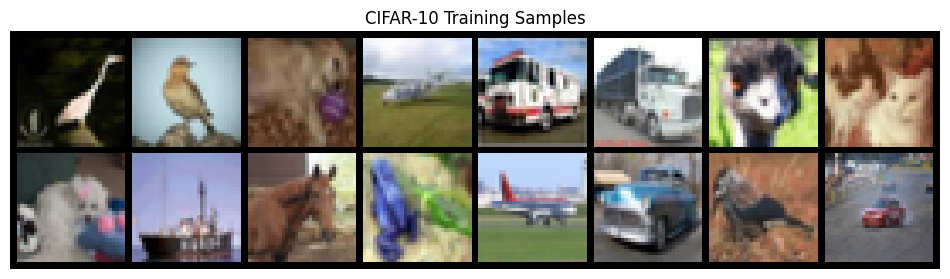

In [3]:
# Visualize some training images
def show_images(images, labels=None, nrow=8, title='Images'):
    """Display a grid of images."""
    # Denormalize from [-1, 1] to [0, 1]
    images = (images + 1) / 2
    images = images.clamp(0, 1)
    
    grid = torchvision.utils.make_grid(images, nrow=nrow, padding=2)
    plt.figure(figsize=(12, 6))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title(title)
    plt.show()

# Show a batch
images, labels = next(iter(train_loader))
show_images(images[:16], nrow=8, title='CIFAR-10 Training Samples')

## 2. U-Net Architecture (using diffusers)

We use `UNet2DModel` from the `diffusers` library. This is the same architecture used in Stable Diffusion and other state-of-the-art models.

Key features:
- **Time conditioning**: Built-in sinusoidal time embeddings
- **Class conditioning**: We add class embeddings via the `class_labels` parameter
- **Attention layers**: Self-attention at lower resolutions for global context
- **Skip connections**: Encoder-decoder architecture with skip connections

In [ ]:
#| label: unet-architecture

# Create U-Net model from diffusers
# Note: diffusers expects time in range [0, num_train_timesteps], not [0, 1]
# We'll scale our t accordingly

model = UNet2DModel(
    sample_size=32,           # Image size (32x32 for CIFAR-10)
    in_channels=3,            # RGB images
    out_channels=3,           # Output vector field has same shape as input
    layers_per_block=2,       # ResNet blocks per resolution level
    block_out_channels=(64, 128, 256, 256),  # Channels at each resolution
    down_block_types=(
        "DownBlock2D",        # 32 -> 16
        "DownBlock2D",        # 16 -> 8
        "AttnDownBlock2D",    # 8 -> 4 (with attention)
        "DownBlock2D",        # 4 -> 2
    ),
    up_block_types=(
        "UpBlock2D",          # 2 -> 4
        "AttnUpBlock2D",      # 4 -> 8 (with attention)
        "UpBlock2D",          # 8 -> 16
        "UpBlock2D",          # 16 -> 32
    ),
    # Class conditioning
    num_class_embeds=NUM_CLASSES + 1,  # +1 for null class (used in CFG)
)

model = model.to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass
# Note: diffusers UNet expects timestep as integer, we'll multiply our t by 1000
x = torch.randn(2, 3, 32, 32, device=device)
t = torch.randint(0, 1000, (2,), device=device)  # timestep as integer
c = torch.randint(0, NUM_CLASSES, (2,), device=device)
out = model(x, t, class_labels=c).sample
print(f"Input shape: {x.shape} -> Output shape: {out.shape}")

<cell_type>markdown</cell_type>## 3. Flow Matching Loss

The key insight of flow matching: we learn a vector field that transports noise to data along straight paths.

**The probability path (Gaussian CondOT):** $x_t = t \cdot z + (1-t) \cdot \epsilon$

- $z \sim p_{\text{data}}$ is a real image
- $\epsilon \sim \mathcal{N}(0, I)$ is noise
- At $t=0$: pure noise $\epsilon$
- At $t=1$: real image $z$

**The conditional vector field:** $u_t(x_t | z) = z - \epsilon$
- This is constant in time! The direction from noise to image is simply their difference.

**The CFM loss:** Train the network to predict this vector field:
$$\mathcal{L}_{\text{CFM}} = \mathbb{E}_{t, z, \epsilon} \left[ \| u_t^\theta(x_t) - (z - \epsilon) \|^2 \right]$$

In [ ]:
#| label: flow-matching-loss

def flow_matching_loss(model, z, class_label, label_dropout=0.1, num_timesteps=1000):
    """Compute the Conditional Flow Matching loss.
    
    Args:
        model: The U-Net that predicts vector fields
        z: Real images (data) from the dataset [B, C, H, W]
        class_label: Class labels [B] (0 to NUM_CLASSES-1)
        label_dropout: Probability of dropping class label (for CFG)
        num_timesteps: Scale factor for time (diffusers convention)
        
    Returns:
        Scalar loss value
    """
    batch_size = z.shape[0]
    device = z.device
    
    # Sample random time t ~ Uniform[0, 1]
    t = torch.rand(batch_size, device=device)
    
    # Sample noise ε ~ N(0, I)
    eps = torch.randn_like(z)
    
    # Compute x_t = t*z + (1-t)*ε (Gaussian CondOT path)
    # Reshape t for broadcasting: [B] -> [B, 1, 1, 1]
    t_expand = t[:, None, None, None]
    xt = t_expand * z + (1 - t_expand) * eps
    
    # Target vector field: u_t(x|z) = z - ε (constant in time!)
    target_vector_field = z - eps
    
    # Apply label dropout for classifier-free guidance
    # Replace some labels with the null class (NUM_CLASSES = 10)
    null_class = NUM_CLASSES  # = 10
    dropout_mask = torch.rand(batch_size, device=device) < label_dropout
    class_label_dropped = torch.where(dropout_mask, null_class, class_label)
    
    # Convert t from [0, 1] to integer timesteps for diffusers
    # diffusers expects timesteps in [0, num_timesteps)
    timesteps = (t * num_timesteps).long().clamp(0, num_timesteps - 1)
    
    # Predict vector field
    predicted_vector_field = model(xt, timesteps, class_labels=class_label_dropped).sample
    
    # MSE loss
    loss = F.mse_loss(predicted_vector_field, target_vector_field)
    
    return loss

## 4. Classifier-Free Guidance

**Problem**: We want to generate images of a *specific* class, not just any random image.

**Solution**: Classifier-Free Guidance (CFG) amplifies the "class signal" during sampling.

During training, we randomly drop class labels (replacing with null class). This teaches the model both:
- Conditional generation: $u_t^\theta(x_t | y)$ -- generate class $y$
- Unconditional generation: $u_t^\theta(x_t | \varnothing)$ -- generate any class

During sampling, we blend both predictions:
$$\tilde{u}_t^\theta(x_t | y) = u_t^\theta(x_t | \varnothing) + w \cdot \bigl(u_t^\theta(x_t | y) - u_t^\theta(x_t | \varnothing)\bigr)$$

Where $w$ is the **guidance scale**:
- $w = 1$: Standard conditional generation
- $w > 1$: Amplified class signal (stronger conditioning)
- $w = 0$: Pure unconditional generation

In [ ]:
#| label: cfg-implementation

class CFGVectorFieldWrapper(nn.Module):
    """Wraps the U-Net to apply classifier-free guidance during sampling.
    
    CFG formula: u_tilde = u_t(x|varnothing) + w * (u_t(x|y) - u_t(x|varnothing))
    """
    
    def __init__(self, model, guidance_scale=2.0, num_timesteps=1000):
        super().__init__()
        self.model = model
        self.guidance_scale = guidance_scale
        self.num_timesteps = num_timesteps
        self.class_label = None  # Set before sampling
    
    def forward(self, t, x):
        """Compute guided vector field for ODE solver.
        
        Note: torchdiffeq expects (t, x) order, where t is scalar in [0, 1].
        """
        batch_size = x.shape[0]
        device = x.device
        
        # Convert scalar t to batch of integer timesteps
        timestep = int(t.item() * self.num_timesteps)
        timestep = min(timestep, self.num_timesteps - 1)
        timesteps = torch.full((batch_size,), timestep, device=device, dtype=torch.long)
        
        # Null class for unconditional prediction
        null_class = torch.full((batch_size,), NUM_CLASSES, device=device, dtype=torch.long)
        
        # Get both conditional and unconditional predictions
        u_uncond = self.model(x, timesteps, class_labels=null_class).sample
        u_cond = self.model(x, timesteps, class_labels=self.class_label).sample
        
        # Apply CFG formula: u_tilde = u_uncond + w * (u_cond - u_uncond)
        u_guided = u_uncond + self.guidance_scale * (u_cond - u_uncond)
        
        return u_guided

## 5. Training Loop

In [ ]:
#| label: training-loop

def train(model, train_loader, epochs=50, lr=2e-4, label_dropout=0.1):
    """Train the flow matching model.
    
    Args:
        model: U-Net model
        train_loader: DataLoader for training images
        epochs: Number of training epochs
        lr: Learning rate
        label_dropout: Probability of dropping class labels for CFG
        
    Returns:
        List of training losses
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    losses = []
    model.train()
    
    for epoch in range(epochs):
        epoch_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for z, y in pbar:  # z = data, y = class labels
            z = z.to(device)
            y = y.to(device)
            
            optimizer.zero_grad()
            loss = flow_matching_loss(model, z, y, label_dropout=label_dropout)
            loss.backward()
            
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            
            optimizer.step()
            
            epoch_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")
    
    return losses

# Hyperparameters
EPOCHS = 50  # Increase for better results (100+ recommended)
LEARNING_RATE = 2e-4
LABEL_DROPOUT = 0.1

# Train the model
losses = train(
    model, train_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    label_dropout=LABEL_DROPOUT
)

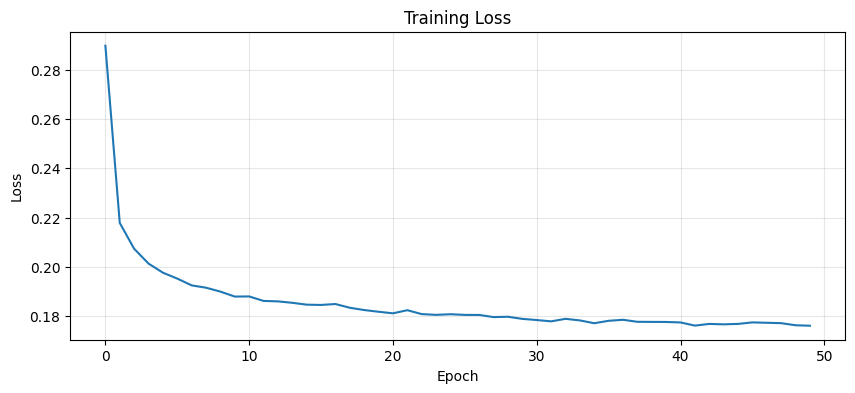

In [8]:
#| label: training-curve

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

<cell_type>markdown</cell_type>## 6. Sampling

To generate images, we:
1. Start with pure noise $\epsilon$ at $t=0$
2. Solve the ODE: $\frac{dx_t}{dt} = u_t^\theta(x_t | y)$
3. Arrive at a generated image at $t=1$

We use `torchdiffeq.odeint` to numerically solve this ODE.

In [ ]:
#| label: sampling

@torch.no_grad()
def sample(model, num_samples, class_label, guidance_scale=2.0, num_steps=50):
    """Generate samples using ODE integration.
    
    Args:
        model: Trained U-Net model
        num_samples: Number of images to generate
        class_label: Class to generate (0-9 for CIFAR-10)
        guidance_scale: CFG guidance scale (higher = stronger conditioning)
        num_steps: Number of ODE solver steps
        
    Returns:
        Generated images [num_samples, 3, 32, 32]
    """
    model.eval()
    
    # Wrap model for CFG
    vector_field_fn = CFGVectorFieldWrapper(model, guidance_scale=guidance_scale)
    vector_field_fn.class_label = torch.full((num_samples,), class_label, device=device, dtype=torch.long)
    
    # Start from noise ε at t=0
    eps = torch.randn(num_samples, 3, 32, 32, device=device)
    
    # Time points for ODE solver (from 0 to 1)
    t_span = torch.linspace(0, 1, num_steps, device=device)
    
    # Solve ODE: dx/dt = u(x, t)
    # odeint returns trajectory at all time points, we want the final one
    trajectory = odeint(
        vector_field_fn,
        eps,
        t_span,
        method='euler',  # Simple Euler method; can use 'dopri5' for adaptive stepping
    )
    
    # Get final samples at t=1
    samples = trajectory[-1]
    
    # Clamp to valid range
    samples = samples.clamp(-1, 1)
    
    return samples


def display_samples(samples, title='Generated Images', nrow=8):
    """Display generated samples in a grid."""
    # Denormalize from [-1, 1] to [0, 1]
    samples = (samples + 1) / 2
    samples = samples.clamp(0, 1)
    
    grid = torchvision.utils.make_grid(samples, nrow=nrow, padding=2)
    plt.figure(figsize=(12, 6))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title(title)
    plt.show()

## 7. Results

Let's generate images for each CIFAR-10 class and see the effect of different guidance scales.

Generating samples for each class...


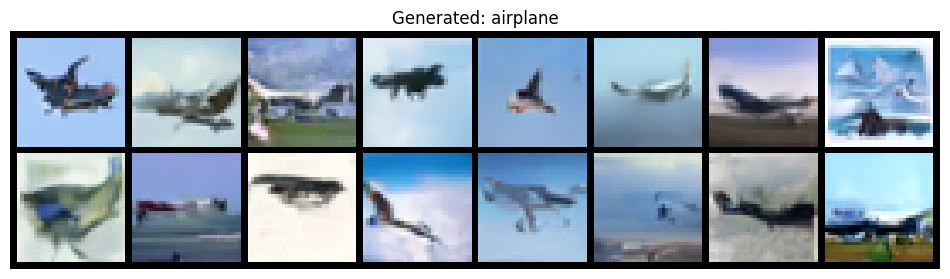

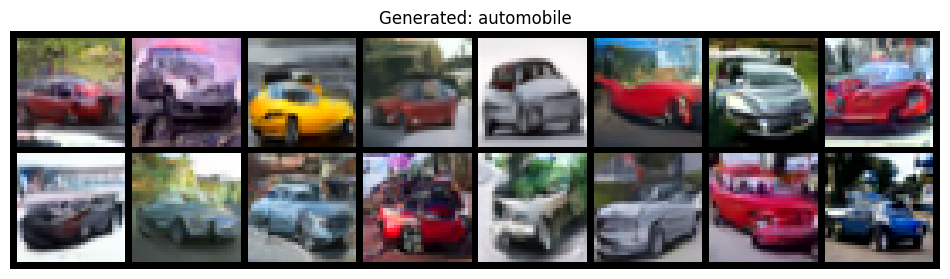

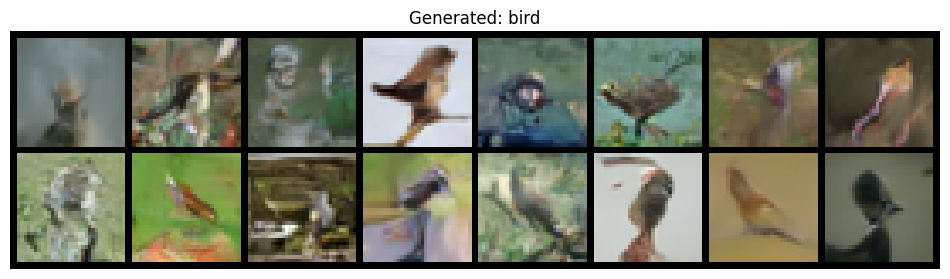

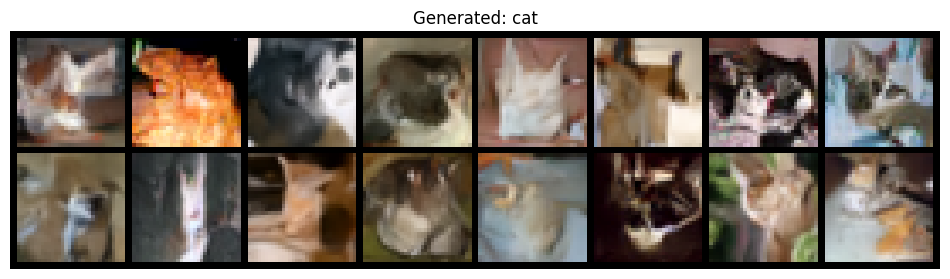

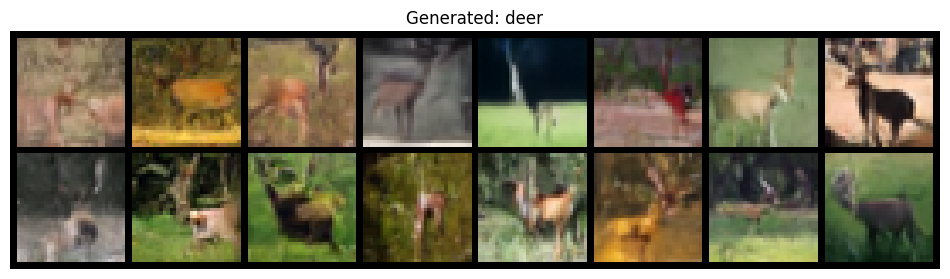

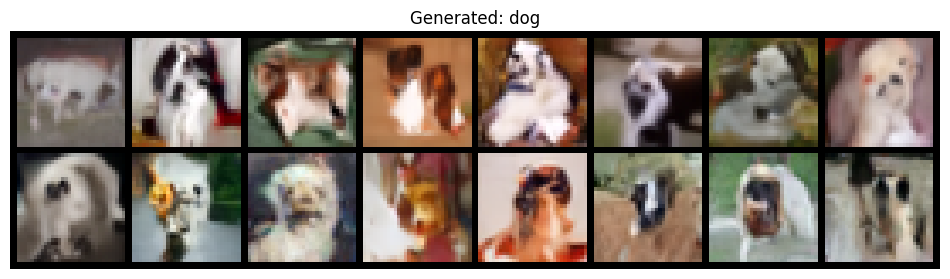

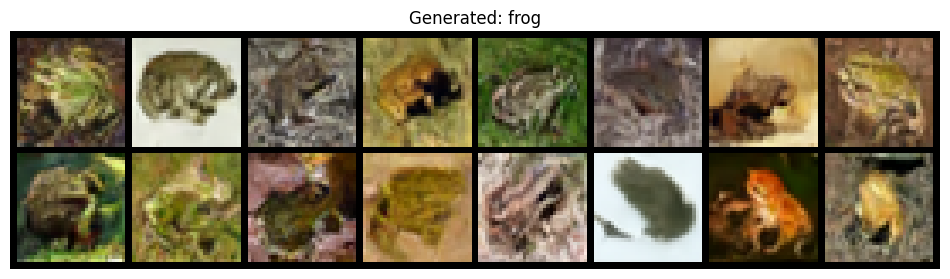

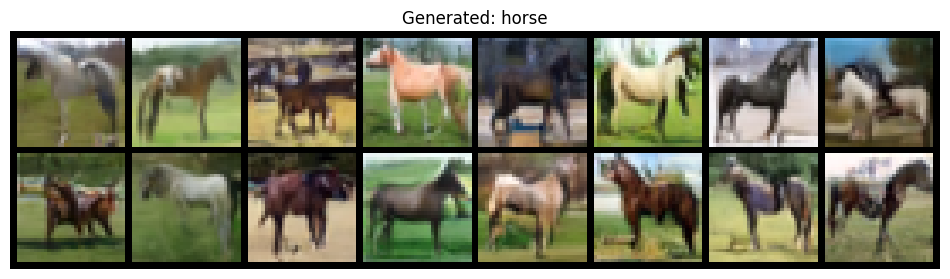

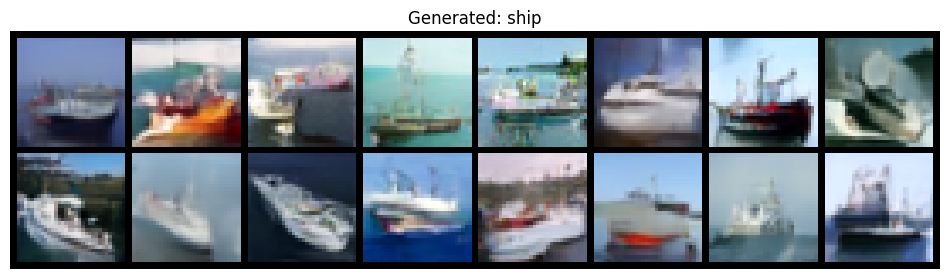

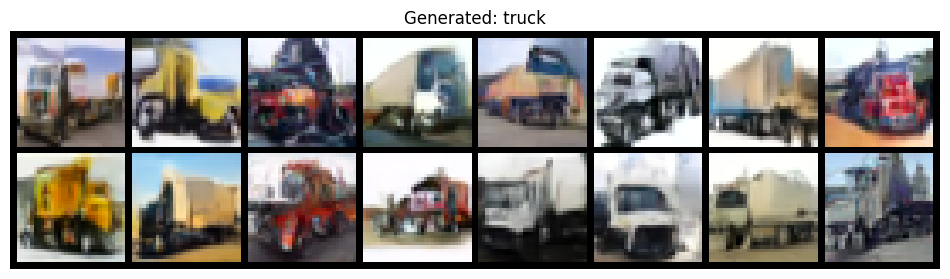

In [10]:
#| label: results

# Generate samples for each class
model.eval()

print("Generating samples for each class...")
for class_idx, class_name in enumerate(CIFAR10_CLASSES):
    samples = sample(model, num_samples=16, class_label=class_idx, guidance_scale=2.0)
    display_samples(samples, title=f'Generated: {class_name}')


Effect of guidance scale on 'airplane' class:


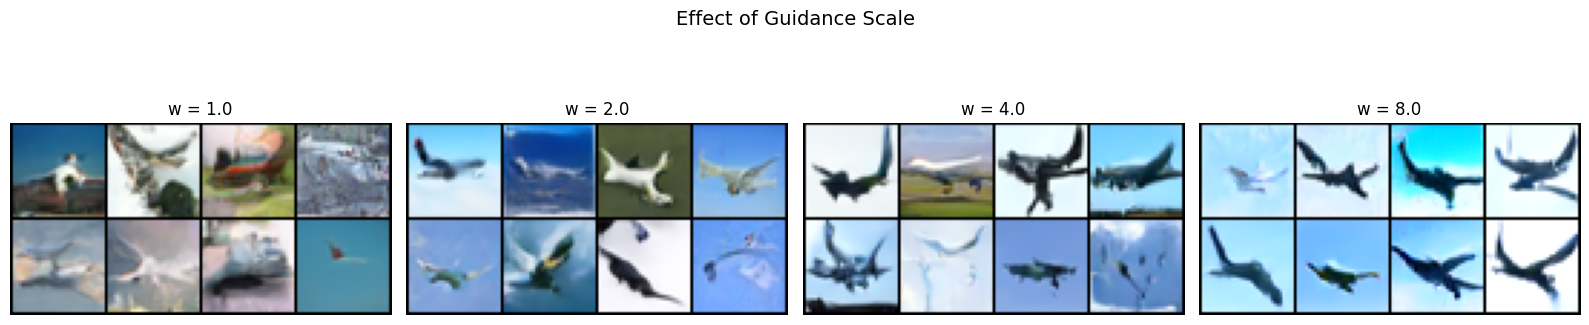

In [11]:
#| label: guidance-comparison

# Compare different guidance scales
print("\nEffect of guidance scale on 'airplane' class:")
guidance_scales = [1.0, 2.0, 4.0, 8.0]

fig, axes = plt.subplots(1, len(guidance_scales), figsize=(16, 4))
for ax, w in zip(axes, guidance_scales):
    samples = sample(model, num_samples=8, class_label=0, guidance_scale=w)  # airplane
    samples = (samples + 1) / 2
    grid = torchvision.utils.make_grid(samples, nrow=4, padding=1)
    ax.imshow(grid.permute(1, 2, 0).cpu())
    ax.set_title(f'w = {w}')
    ax.axis('off')

plt.suptitle('Effect of Guidance Scale', fontsize=14)
plt.tight_layout()
plt.show()

## Summary

We built a conditional image generator using flow matching:

1. **U-Net architecture** (from `diffusers`) with time and class conditioning
2. **Gaussian CondOT path**: $x_t = t \cdot z + (1-t) \cdot \epsilon$ where $z$ is data, $\epsilon$ is noise
3. **Flow matching loss**: Learn to predict the vector field $u_t^\theta(x_t) \approx z - \epsilon$
4. **Classifier-free guidance**: Amplify class signal during sampling
5. **ODE sampling**: Integrate from noise ($t=0$) to image ($t=1$) using `torchdiffeq`

### Key takeaways:
- Flow matching is conceptually simple: just learn the direction from noise to data
- The same architecture powers Stable Diffusion, Flux, and other SOTA models
- CFG is crucial for high-quality conditional generation

### Extensions to try:
- Use a DiT (Diffusion Transformer) instead of U-Net (see Part 10)
- Train on larger datasets (ImageNet, LAION)
- Try different ODE solvers (adaptive stepping with `dopri5`)
- Add EMA (exponential moving average) for better sample quality

In [12]:
# Save the trained model
torch.save(model.state_dict(), 'flow_matching_cifar10.pt')
print("Model saved to flow_matching_cifar10.pt")

Model saved to flow_matching_cifar10.pt
